# 블랙아이스 발생 시각화
초음파 거리, 노면 온도, 대기 온도, 조도(LDR), 습도 센서 데이터와 블랙아이스 발생 여부 간의 상관관계를 시각화합니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 폰트 설정 초기화 (이전 커널 메모리에 남은 NanumGothic 설정 제거)
plt.rcdefaults()

# 데이터 로드
df = pd.read_csv('measurements.csv')
# 상태가 'unknown'인 데이터는 시각화의 명확성을 위해 제외
df = df[df['black_ice_status'].isin(['occurred', 'not_occurred'])]
df.head()

,measured_at,date,time,measurement_duration_sec,measurement_interval_sec,distance_cm_avg,ldr_avg,temperature,road_surface_temp,humidity,location,black_ice_status,photo_filename,photo_saved,photo_error,samples_taken,samples_total
0,2026-02-10T08:39:33+09:00,2026-02-10,08:39:33,30.0,5.0,204.336532,225.000000,0.1,-0.2,43.2,1,not_occurred,2026-02-10T08:39:33+09:00.jpg,True,NaN,3,6
1,2026-02-10T08:53:55+09:00,2026-02-10,08:53:55,30.0,5.0,98.984084,325.666667,-0.2,1.5,47.5,2,occurred,2026-02-10T08:53:55+09:00.jpg,True,NaN,3,6
2,2026-02-10T09:03:36+09:00,2026-02-10,09:03:36,30.0,5.0,74.216625,362.166667,-0.1,-0.4,47.8,3,not_occurred,2026-02-10T09:03:36+09:00.jpg,True,NaN,6,6
3,2026-02-10T09:12:06+09:00,2026-02-10,09:12:06,30.0,5.0,79.596580,442.200000,-0.1,1.0,48.5,4,occurred,2026-02-10T09:12:06+09:00.jpg,True,NaN,5,6
4,2026-02-10T09:33:47+09:00,2026-02-10,09:33:47,30.0,5.0,153.603973,524.500000,0.2,3.8,43.1,5,occurred,2026-02-10T09:33:47+09:00.jpg,True,NaN,2,6


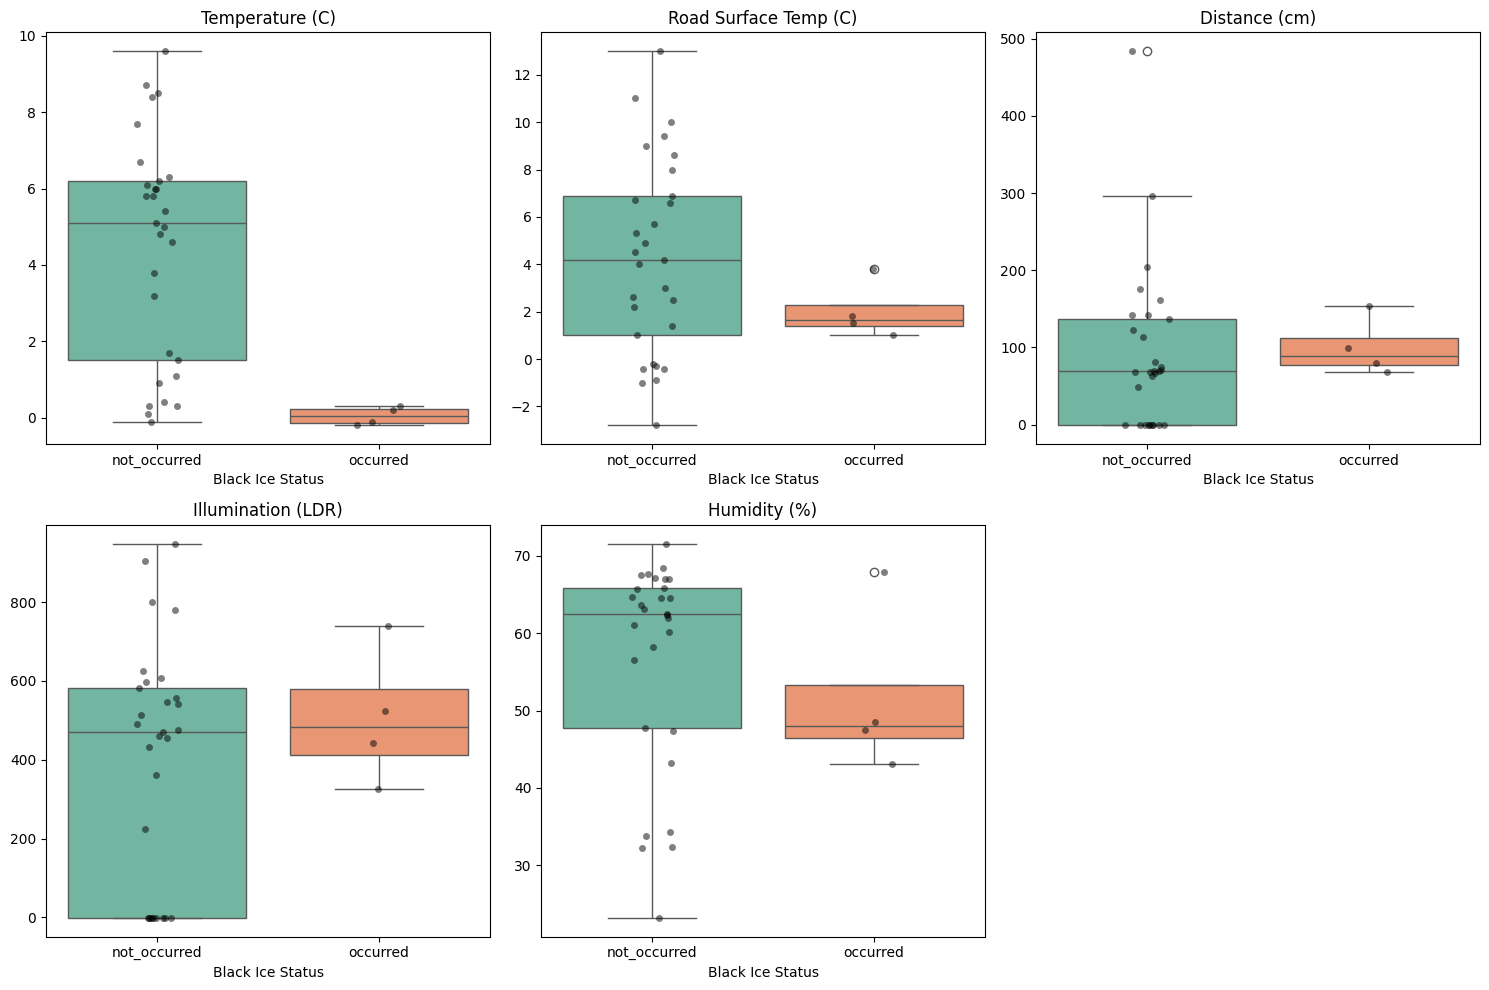

In [2]:
# 분석할 센서 특성들
features = ['temperature', 'road_surface_temp', 'distance_cm_avg', 'ldr_avg', 'humidity']
titles = ['Temperature (C)', 'Road Surface Temp (C)', 'Distance (cm)', 'Illumination (LDR)', 'Humidity (%)']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# 각 변수별로 블랙아이스 발생 여부에 따른 박스플롯(Boxplot) 그리기
for i, (col, title) in enumerate(zip(features, titles)):
    sns.boxplot(x='black_ice_status', y=col, data=df, ax=axes[i], order=['not_occurred', 'occurred'], palette='Set2')
    sns.stripplot(x='black_ice_status', y=col, data=df, ax=axes[i], order=['not_occurred', 'occurred'], color='black', alpha=0.5)
    axes[i].set_title(title)
    axes[i].set_xlabel('Black Ice Status')
    axes[i].set_ylabel('')

# 6번째 빈 그래프 숨기기
axes[5].axis('off')

plt.tight_layout()
plt.show()

위의 박스플롯을 보면 발생 여부를 판가름 짓는 강력한 요인은 **온도와 노면 온도** 임을 알 수 있습니다. 
이 두 가지 핵심 변수를 산점도(Scatter Plot)로 그려서 더 명확히 확인해봅니다.

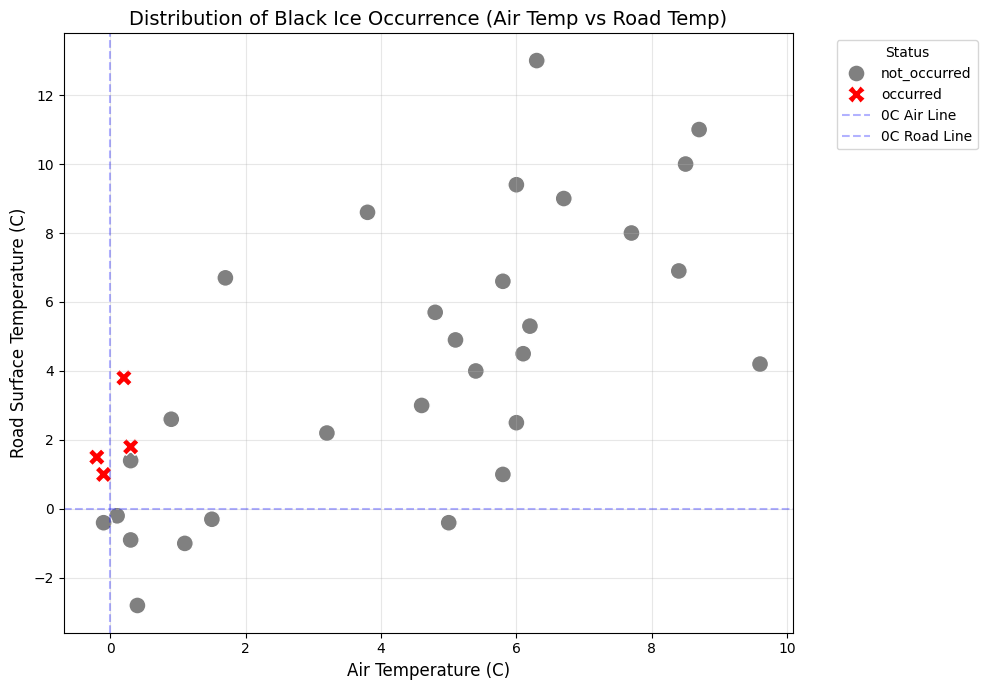

In [3]:
# 산점도를 통한 2차원 관계 시각화 (대기 온도 vs 노면 온도)
plt.figure(figsize=(10, 7))

sns.scatterplot(x='temperature', y='road_surface_temp', hue='black_ice_status', 
                style='black_ice_status', s=150, data=df, palette={'not_occurred': 'gray', 'occurred': 'red'})

plt.title('Distribution of Black Ice Occurrence (Air Temp vs Road Temp)', fontsize=14)
plt.xlabel('Air Temperature (C)', fontsize=12)
plt.ylabel('Road Surface Temperature (C)', fontsize=12)

# 0도 기준선 그리기
plt.axvline(x=0, color='blue', linestyle='--', alpha=0.3, label='0C Air Line') 
plt.axhline(y=0, color='blue', linestyle='--', alpha=0.3, label='0C Road Line') 

plt.grid(True, alpha=0.3)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 시간에 따른 온도 변화 및 블랙아이스 발생 시점 (Line Chart)
측정 시간에 따른 대기 온도와 노면 온도의 추이를 확인하고, 블랙아이스가 발생한 특정 시점을 파악합니다.

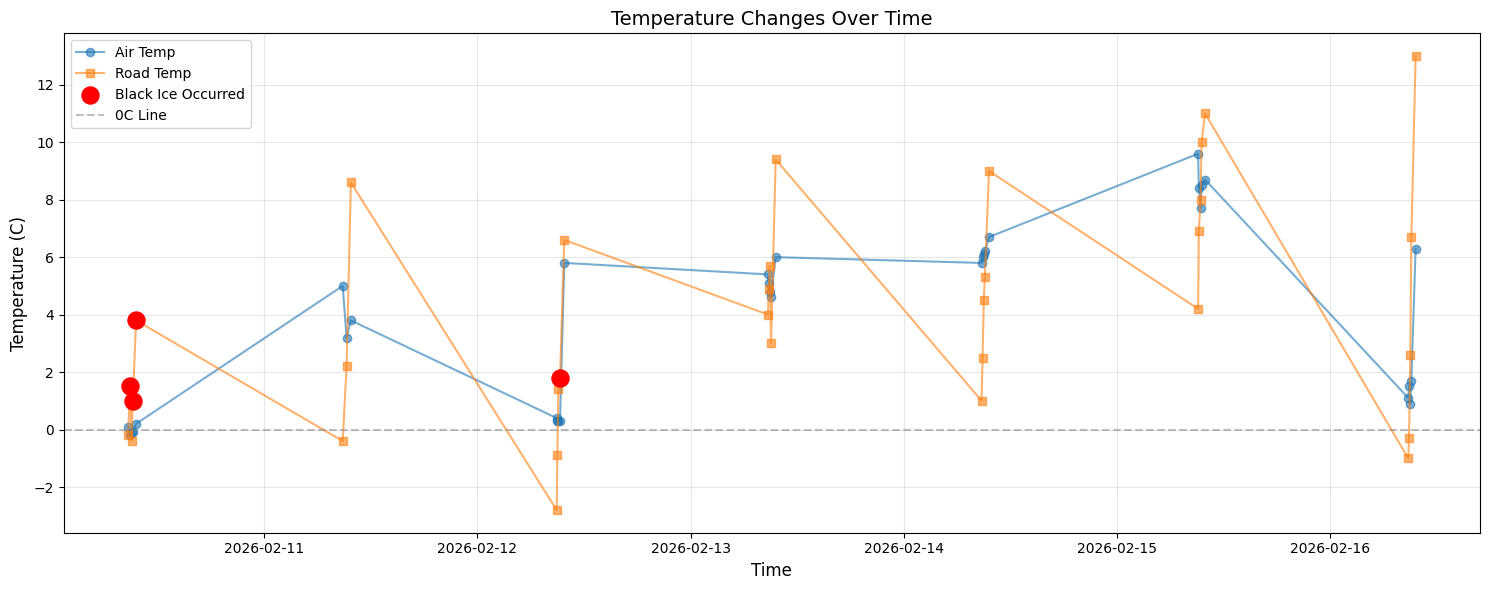

In [4]:
# 시간을 datetime 객체로 변환하고 시간순으로 정렬
df['measured_at'] = pd.to_datetime(df['measured_at'])
df_time = df.sort_values('measured_at')

plt.figure(figsize=(15, 6))

# 대기 온도와 노면 온도 변화 추이
plt.plot(df_time['measured_at'], df_time['temperature'], label='Air Temp', marker='o', alpha=0.6)
plt.plot(df_time['measured_at'], df_time['road_surface_temp'], label='Road Temp', marker='s', alpha=0.6)

# 블랙아이스가 발생한 시점만 빨간색 큰 점으로 표시
occurred_df = df_time[df_time['black_ice_status'] == 'occurred']
plt.scatter(occurred_df['measured_at'], occurred_df['road_surface_temp'], 
            color='red', s=150, zorder=5, label='Black Ice Occurred')

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='0C Line')
plt.title('Temperature Changes Over Time', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Temperature (C)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 블랙아이스 발생 여부에 따른 평균 센서값 비교 (Bar Chart)
블랙아이스가 발생했을 때와 발생하지 않았을 때의 평균 대기 온도, 노면 온도, 습도를 비교합니다.

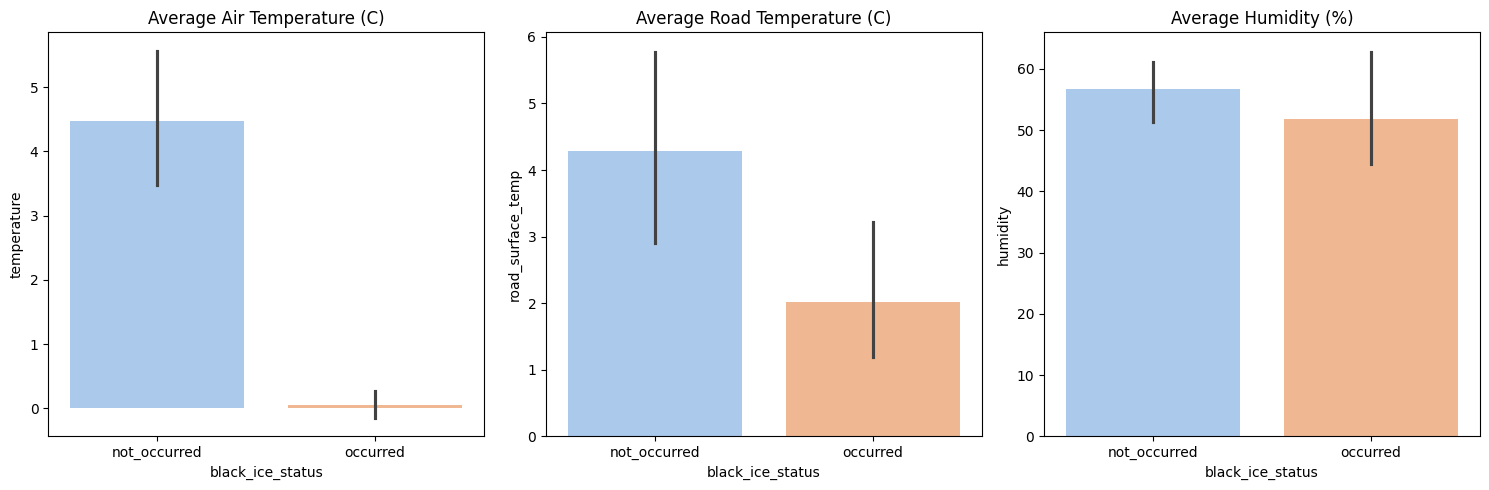

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(x='black_ice_status', y='temperature', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Average Air Temperature (C)')

sns.barplot(x='black_ice_status', y='road_surface_temp', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Average Road Temperature (C)')

sns.barplot(x='black_ice_status', y='humidity', data=df, ax=axes[2], palette='pastel')
axes[2].set_title('Average Humidity (%)')

plt.tight_layout()
plt.show()

### 통계 요약 표 (Summary Table)
발생 여부에 따른 각 센서별 정확한 평균 수치를 표로 확인합니다.

In [6]:
summary_table = df.groupby('black_ice_status')[['temperature', 'road_surface_temp', 'humidity', 'ldr_avg']].mean()
summary_table.columns = ['Avg Air Temp (C)', 'Avg Road Temp (C)', 'Avg Humidity (%)', 'Avg LDR']
summary_table = summary_table.round(2)
display(summary_table)

,Avg Air Temp (C),Avg Road Temp (C),Avg Humidity (%),Avg LDR
black_ice_status,,,,
not_occurred,4.48,4.29,56.75,391.89
occurred,0.05,2.02,51.75,508.22


### 지도 위에 블랙아이스 발생 위치 및 날씨/측정 데이터 통합 표시
각 관측소 위치별로 블랙아이스 발생 기록을 지도(Map)에 표시합니다. 빨간색 마커는 블랙아이스 발생, 회색 마커는 미발생을 나타냅니다. 마커를 클릭하면 **센서 측정 데이터**와 가장 근접한 시간대의 **기상청(KMA) 날씨 데이터**를 함께 비교해 볼 수 있습니다.

In [7]:
import folium
from datetime import datetime
from analyze_weather import load_weather_data, find_closest_weather

# 가상의 성북구 관측소 위치 좌표 (위도, 경도) - 시각화를 위해 임의 지정
location_coords = {
    1: [37.604, 127.032],
    2: [37.605, 127.045],
    3: [37.592, 127.016],
    4: [37.590, 127.025],
    5: [37.610, 127.010]
}

# 성북구 중심 지도 생성
m = folium.Map(location=[37.598, 127.026], zoom_start=14)

weather_cache = {}

# 데이터프레임의 모든 기록을 지도에 마커로 표시
for idx, row in df.iterrows():
    dt = row['measured_at'].to_pydatetime()
    date_str = dt.strftime('%Y-%m-%d')
    
    # 날씨 데이터 로드 (캐싱)
    if date_str not in weather_cache:
        weather_cache[date_str] = load_weather_data(date_str)
        
    weather_data = weather_cache[date_str]
    
    kma_info = "<span style='color:gray'>기상청 데이터 없음</span>"
    if weather_data:
        closest_time, kma = find_closest_weather(weather_data, dt)
        if kma:
            kma_info = f"<b>기상청({closest_time[-4:-2]}:{closest_time[-2:]}):</b> 온도 {kma['ta']:.1f}C, 비/눈 {kma['rn']:.1f}mm, 습도 {kma['hm']:.1f}%"
            
    loc_id = row['location']
    coords = location_coords.get(loc_id, [37.598, 127.026])
    
    # 마커가 겹치지 않도록 미세하게 좌표 이동
    offset_lat = coords[0] + (idx % 10) * 0.0003
    offset_lon = coords[1] + (idx % 10) * 0.0003
    
    status = row['black_ice_status']
    color = 'red' if status == 'occurred' else 'gray'
    icon_type = 'info-sign' if status == 'occurred' else 'ok-circle'
    
    time_str = dt.strftime('%Y-%m-%d %H:%M:%S')
    popup_html = f"""
    <div style='width:250px;'>
        <b>Location: {loc_id}</b><br>
        <b>시간:</b> {time_str}<br>
        <b>상태:</b> <span style='color:{color}; font-weight:bold;'>{status.upper()}</span><hr style='margin:5px 0;'>
        <b>센서 대기온도:</b> {row['temperature']}C<br>
        <b>센서 노면온도:</b> {row['road_surface_temp']}C<br>
        <b>센서 습도:</b> {row['humidity']}%<hr style='margin:5px 0;'>
        {kma_info}
    </div>
    """
    
    folium.Marker(
        location=[offset_lat, offset_lon],
        popup=folium.Popup(popup_html, max_width=300),
        icon=folium.Icon(color=color, icon=icon_type)
    ).add_to(m)

m